In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_import = pd.read_csv("./data/housing.csv")`

In [8]:
data_clean

,beds,baths,size,price
0,3,2.5,2590.0,795000.0
1,4,2.0,2240.0,915000.0
2,4,3.0,2040.0,950000.0
3,4,3.0,3800.0,1950000.0
4,2,2.0,1042.0,950000.0
...,...,...,...,...
2011,3,2.0,1370.0,910000.0
2012,1,1.0,889.0,550000.0
2013,4,2.0,2140.0,1150000.0
2014,2,2.0,795.0,590000.0


In [5]:
data_clean = data_import.drop(columns=["Unnamed: 0", "zip_code"])

In [64]:
def compute_gradient(x_train, y_train, w, b, lamba):
    m,n = x_train.shape
    dj_dw = np.zeros(n).ravel()
    dj_db = 0

    # print(f"lamba{(lamba/m)*w}")

    
    pred = (x_train@w+b)
    error = pred - y_train
    dj_dw += error @ x_train/m
    dj_db += np.sum(error)/m

    dj_dw += (lamba/m) * w

    return dj_dw, dj_db

In [62]:
def run_gradient(x_train, y_train, alpha, epochs, lamba):
    m, n = x_train.shape
    w = np.zeros(n)
    b = 0

    for i in range(epochs):
        dw, db = compute_gradient(x_train, y_train, w, b, lamba)

        w = w - alpha * dw
        b = b - alpha * db

        if i%20 == 0:
            print(f"weight:{w}, bais:{b}")

    return w, b

In [10]:
def z_score_normalization(data):
    mean_ = np.mean(data, axis=0)
    std_ = np.std(data, axis=0)

    return (data-mean_)/std_

In [11]:
norm = z_score_normalization(np.array(data_clean))
norm

array([[ 0.11345495,  0.33942758,  0.9286394 , -0.17865468],
       [ 0.91040676, -0.15968693,  0.54816506, -0.05151734],
       [ 0.91040676,  0.83854209,  0.33075115, -0.01443562],
       ...,
       [ 0.91040676, -0.15968693,  0.4394581 ,  0.19745993],
       [-0.68349687, -0.15968693, -1.02265042, -0.39584762],
       [ 0.11345495, -0.15968693, -0.0279818 , -0.32274365]],
      shape=(2016, 4))

In [22]:
x_train, y_train = norm[:, 0:-1], norm[:, -1].ravel()
print(x_train.shape, y_train.shape)

(2016, 3) (2016,)


In [65]:
w, b = run_gradient(x_train, y_train, 0.1, 1000, 1)

weight:[0.02935156 0.03173246 0.04441403], bais:1.7622587692462802e-19
weight:[0.03903385 0.10774333 0.29005935], bais:-2.6610107415618832e-17
weight:[-0.02757125  0.09232737  0.37213059], bais:-2.837236618486511e-17
weight:[-0.07077206  0.08408146  0.42283231], bais:-2.9605947323337495e-17
weight:[-0.09843346  0.07969507  0.45445068], bais:-3.577385301569946e-17
weight:[-0.11606926  0.07730714  0.47422404], bais:-4.2117984584986065e-17
weight:[-0.12727888  0.07597685  0.48661557], bais:-4.2470436338835313e-17
weight:[-0.13438821  0.07521946  0.49439312], bais:-4.2999113969609196e-17
weight:[-0.13888983  0.0747797   0.49928033], bais:-4.1765532831136804e-17
weight:[-0.14173691  0.07451996  0.50235394], bais:-4.1765532831136804e-17
weight:[-0.14353603  0.07436433  0.50428819], bais:-4.352779160038308e-17
weight:[-0.14467221  0.07426999  0.50550599], bais:-4.2294210461910686e-17
weight:[-0.1453894   0.07421226  0.50627298], bais:-4.24704363388353e-17
weight:[-0.14584196  0.07417668  0.50

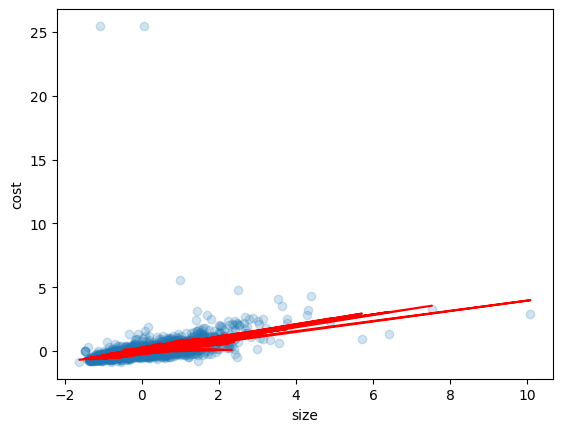

In [77]:
plt.scatter(x_train[:, -1], y_train, alpha=0.2)
plt.plot(x_train[:, -1], x_train@w+b, color="red")
plt.xlabel("size")
plt.ylabel("cost")
plt.show()

In [74]:
x_plot = np.linspace(np.min(x_train[:, -1]), np.max(x_train[:, -1]), 100)

In [79]:
a = x_train@w+b

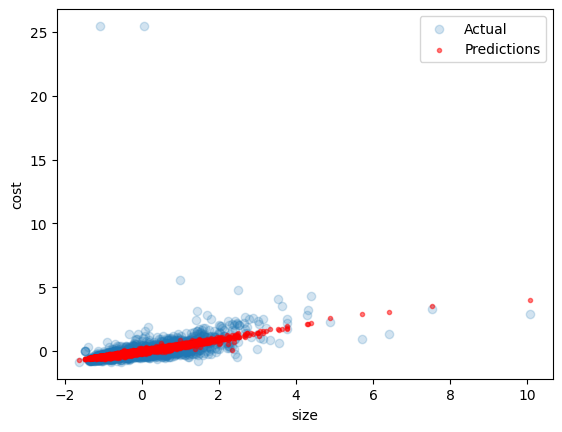

In [84]:
plt.scatter(x_train[:, -1], y_train, alpha=0.2, label="Actual")
plt.scatter(x_train[:, -1], x_train @ w + b, color="red", alpha=0.5, marker='.', label="Predictions")

plt.xlabel("size")
plt.ylabel("cost")
plt.legend()
plt.show()